In [1]:
import pandas as pd

import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json 
import seaborn as sns 

from modsteer import PROJECT_ROOT

In [5]:
plt.rcParams.update(
    {
        "text.usetex": True, 
        "font.family": "serif", 
        "axes.titlesize": 24,        # Larger axes/title fonts
        "legend.fontsize": 24, 
    }
)
sns.set_context("talk")

In [2]:
palette_name = '6_colors'
palette = json.load(open(f'{PROJECT_ROOT}/misc/palettes/{palette_name}.json', 'r'))

In [3]:
palette

{'Dark slate gray': '#335c67',
 'Vanilla': '#fff3b0',
 'Hunyadi yellow': '#e09f3e',
 'Auburn': '#9e2a2b',
 'Chocolate cosmos': '#540b0e',
 'Cambridge blue': '#81b29a'}

### Steering uppercase acc vs layer

In [5]:
accuracies = [0,  0,  0,  0,  0,  0,  0,  0,  0.0,  0.0,  0.25,  0.2,  0.35,  0.3,  0.3,  0.85,  0.55,  0.95,  1.0,  0.8,  0.5,  0.75,  0.65,  0.65,  0.3,  0.15]

In [6]:
# plt.figure(figsize=(8, 6))
# plt.plot(range(1, 27), accuracies, marker='o', color=palette['Cambridge blue'])
# plt.xticks(range(1, 27))
# plt.xlabel('Layer')
# plt.ylabel('Uppercase Accuracy')
# plt.title('Steering Uppercase Accuracy vs Layer')

## Get sweep results

In [7]:
PROJECT_ROOT / "results/original_refusal_-2"

PosixPath('/root/modular-steering-vectors/results/original_refusal_-2')

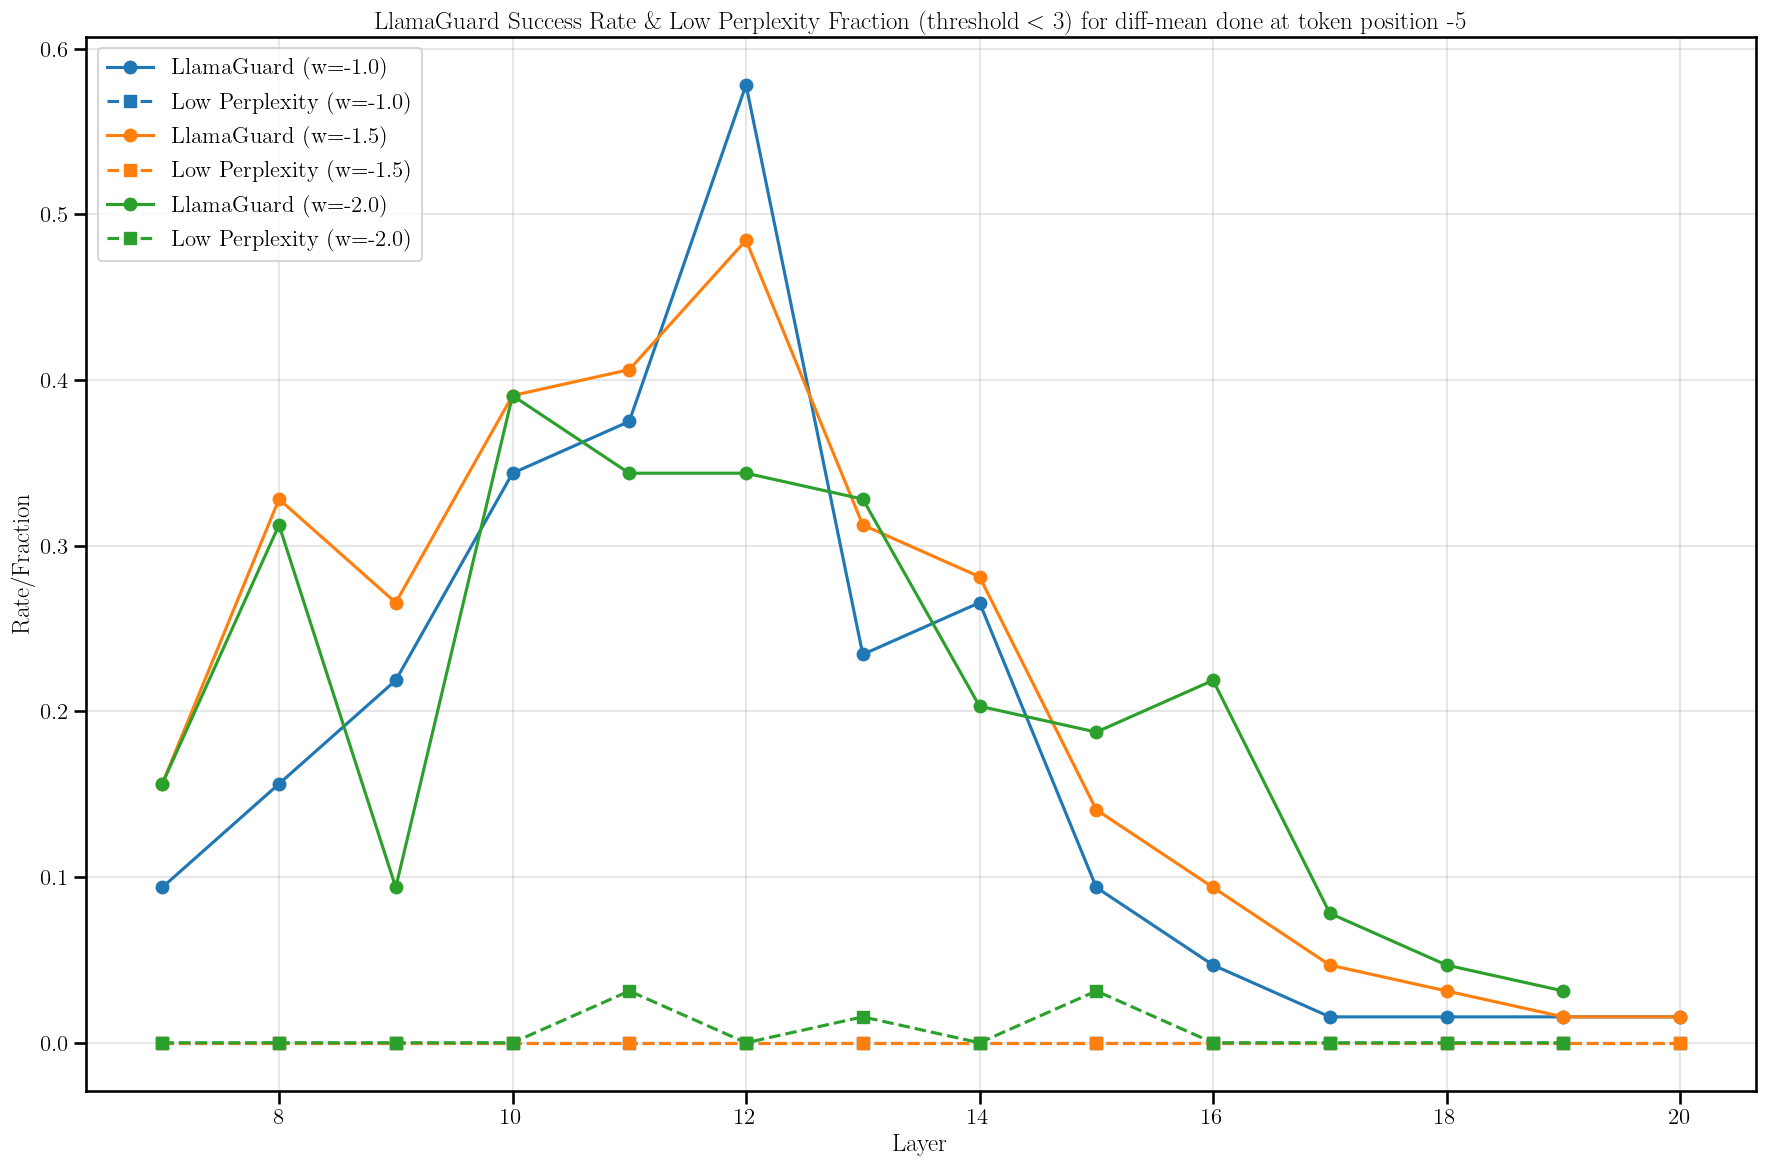

In [15]:
%matplotlib inline

import json
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
results_dir = PROJECT_ROOT / "results/original_refusal_-5"
tok_pos = int(results_dir.name.split("_")[-1])
layers = range(7, 21)
weights = [-1.0, -1.5, -2.0]
perplexity_threshold = 3

# Collect data
llamaguard_data = {}
low_perplexity_data = {}

for w in weights:
    llamaguard_data[w] = []
    low_perplexity_data[w] = []
    
    for l in layers:
        file = results_dir / f"refusal_test_eval_L{l}_w{w}.json"
        if file.exists():
            with open(file) as f:
                result = json.load(f)
                
                # Get llamaguard metric
                llamaguard_data[w].append(result["llamaguard2_success_rate"])
                
                # Calculate low perplexity fraction
                completions = result["completions"]
                low_perp_count = sum(1 for c in completions if c["perplexity"] < perplexity_threshold)
                low_perp_fraction = low_perp_count / len(completions) if completions else 0
                low_perplexity_data[w].append(low_perp_fraction)
        else:
             llamaguard_data[w].append(None)
             low_perplexity_data[w].append(None)
            

# Plot everything in one figure
plt.figure(figsize=(18, 12))

colors = ['C0', 'C1', 'C2']  # Use default color cycle

for i, w in enumerate(weights):
    plt.plot(layers, llamaguard_data[w], marker='o', linestyle='-', 
             color=colors[i], label=f'LlamaGuard (w={w})')
    plt.plot(layers, low_perplexity_data[w], marker='s', linestyle='--', 
             color=colors[i], label=f'Low Perplexity (w={w})')

plt.title(rf'LlamaGuard Success Rate \& Low Perplexity Fraction (threshold $<$ {perplexity_threshold}) for diff-mean done at token position {tok_pos}')
plt.xlabel('Layer')
plt.ylabel('Rate/Fraction')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

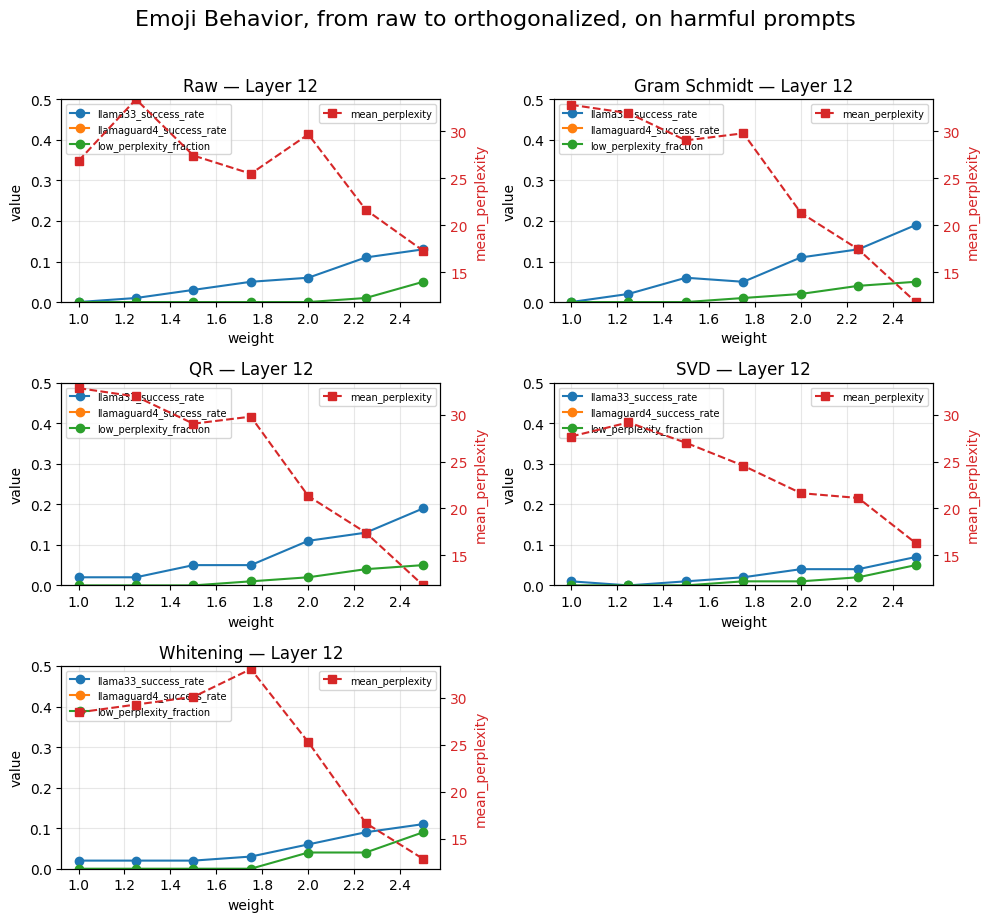

In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
FILE_PATHS = [
    "/workspace/modular-steering-vectors/results/emoji_Llama-3.1-8B-Instruct/results",
    "/workspace/modular-steering-vectors/results/emoji_Llama-3.1-8B-Instruct_gram_schmidt/results",
    "/workspace/modular-steering-vectors/results/emoji_Llama-3.1-8B-Instruct_qr/results",
    "/workspace/modular-steering-vectors/results/emoji_Llama-3.1-8B-Instruct_svd/results",
   "/workspace/modular-steering-vectors/results/emoji_Llama-3.1-8B-Instruct_whitening/results",
]
LABELS = ["Raw", "Gram Schmidt", "QR", "SVD", "Whitening"]  # Column labels
# -------------------------------------------

# Load data
dfs = []
for path in FILE_PATHS:
    with open(path, "r") as f:
        data = json.load(f)
    dfs.append(pd.DataFrame(data))

# Get all layers and metrics
all_layers = sorted(set().union(*[df["layer"].unique() for df in dfs]))
metric_cols = sorted(set(dfs[0].columns) - {"layer", "weight", "mean_perplexity", "llamaguard2_success_rate", "steering_success_rate"})

# Find global min/max for mean_perplexity across all dataframes
all_perplexities = []
for df in dfs:
    if "mean_perplexity" in df.columns:
        all_perplexities.extend(df["mean_perplexity"].dropna().tolist())
perplexity_min = min(all_perplexities) if all_perplexities else 0
perplexity_max = max(all_perplexities) if all_perplexities else 1

# Create plot: rows = len(FILE_PATHS) / 2, columns = 2
num_plots = len(FILE_PATHS)
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 3*num_rows))
axes = axes.flatten()  # Flatten to make indexing easier

fig.suptitle("Emoji Behavior, from raw to orthogonalized, on harmful prompts", fontsize=16, y=1.02)


for idx, (df, label) in enumerate(zip(dfs, LABELS)):
    ax = axes[idx]
    ax2 = ax.twinx()  # Create second y-axis for perplexity
    
    # Assuming we want to plot all layers together or just the first layer
    # Let's plot the first layer for simplicity
    layer = all_layers[0] if all_layers else None
    
    if layer is not None:
        sub = df[df["layer"] == layer].sort_values("weight")
        
        ax.set_title(f"{label} — Layer {layer}")
        ax.set_xlabel("weight")
        ax.set_ylabel("value")
        ax2.set_ylabel("mean_perplexity", color='tab:red')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 0.5)
        ax2.set_ylim(perplexity_min, perplexity_max)  # Set consistent y-axis scale
        
        if not sub.empty:
            for metric in metric_cols:
                if metric in sub.columns:
                    ax.plot(sub["weight"], sub[metric], marker="o", label=metric)
            
            # Plot mean_perplexity on second y-axis
            if "mean_perplexity" in sub.columns:
                ax2.plot(sub["weight"], sub["mean_perplexity"], marker="s", 
                        color='tab:red', label="mean_perplexity", linestyle='--')
                ax2.tick_params(axis='y', labelcolor='tab:red')
            
            ax.legend(fontsize=7, loc="upper left")
            if "mean_perplexity" in sub.columns:
                ax2.legend(fontsize=7, loc="upper right")

# Hide any unused subplots
for idx in range(num_plots, len(axes)):
    axes[idx].axis('off')

fig.tight_layout()
plt.show()

In [8]:
import torch
print(torch.load("/root/modular-steering-vectors/stored_vectors/innocuous_directions_llama-3.1-8b-instruct_brand_raw.pt").norm())
print(torch.load("/root/modular-steering-vectors/stored_vectors/innocuous_directions_llama-3.1-8b-instruct_brand_safe_gram_schmidt.pt").norm())
print(torch.load("/root/modular-steering-vectors/stored_vectors/innocuous_directions_llama-3.1-8b-instruct_brand_safe_mean_null.pt").norm())
print(torch.load("/root/modular-steering-vectors/stored_vectors/innocuous_directions_llama-3.1-8b-instruct_brand_safe_qr.pt").norm())
print(torch.load("/root/modular-steering-vectors/stored_vectors/innocuous_directions_llama-3.1-8b-instruct_brand_safe_whitening.pt").norm())
print(torch.load("/root/modular-steering-vectors/stored_vectors/innocuous_directions_llama-3.1-8b-instruct_brand_safe_svd.pt").norm())



tensor(0.9647, device='cuda:0')
tensor(0.9647, device='cuda:0')
tensor(0.9647, device='cuda:0')
tensor(0.9647, device='cuda:0')
tensor(nan, device='cuda:0')
tensor(0.9647, device='cuda:0')


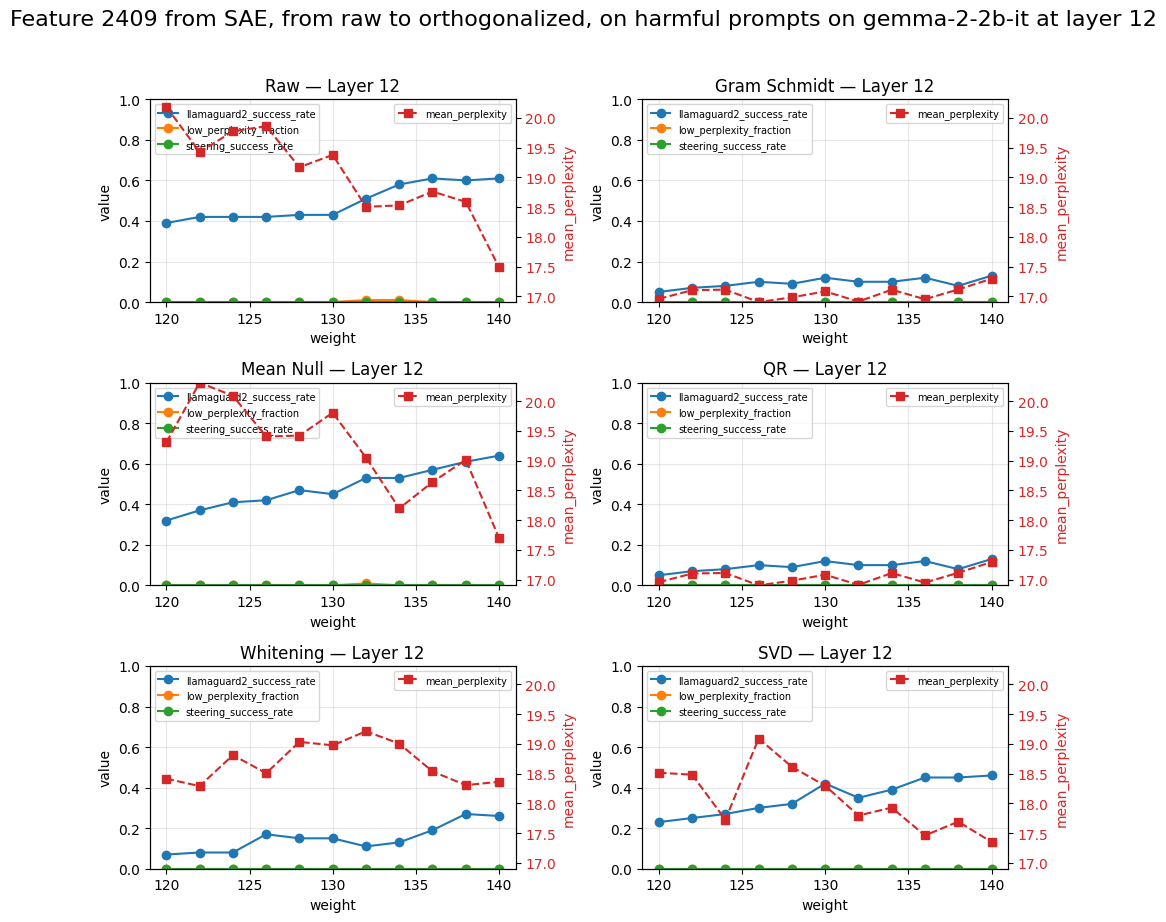

In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
FILE_PATHS = [
    "/root/modular-steering-vectors/results/feature_2409/results",
    "/root/modular-steering-vectors/results/feature_2409/safe_gram_schmidt/results",
    "/root/modular-steering-vectors/results/feature_2409/safe_mean_null/results",
    "/root/modular-steering-vectors/results/feature_2409/safe_qr/results",
    "/root/modular-steering-vectors/results/feature_2409/safe_whitening/results",
    "/root/modular-steering-vectors/results/feature_2409/safe_svd/results",
]
LABELS = ["Raw", "Gram Schmidt", "Mean Null", "QR", "Whitening", "SVD"]  # Column labels
# -------------------------------------------

# Load data
dfs = []
for path in FILE_PATHS:
    with open(path, "r") as f:
        data = json.load(f)
    dfs.append(pd.DataFrame(data))

# Get all layers and metrics
all_layers = sorted(set().union(*[df["layer"].unique() for df in dfs]))
metric_cols = sorted(set(dfs[0].columns) - {"layer", "weight", "mean_perplexity"})

# Find global min/max for mean_perplexity across all dataframes
all_perplexities = []
for df in dfs:
    if "mean_perplexity" in df.columns:
        all_perplexities.extend(df["mean_perplexity"].dropna().tolist())
perplexity_min = min(all_perplexities) if all_perplexities else 0
perplexity_max = max(all_perplexities) if all_perplexities else 1

# Create plot: rows = len(FILE_PATHS) / 2, columns = 2
num_plots = len(FILE_PATHS)
num_cols = 2
num_rows = (num_plots + num_cols - 1) // num_cols  # Ceiling division

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 3*num_rows))
axes = axes.flatten()  # Flatten to make indexing easier

fig.suptitle("Feature 2409 from SAE, from raw to orthogonalized, on harmful prompts on gemma-2-2b-it at layer 12", fontsize=16, y=1.02)


for idx, (df, label) in enumerate(zip(dfs, LABELS)):
    ax = axes[idx]
    ax2 = ax.twinx()  # Create second y-axis for perplexity
    
    # Assuming we want to plot all layers together or just the first layer
    # Let's plot the first layer for simplicity
    layer = all_layers[0] if all_layers else None
    
    if layer is not None:
        sub = df[df["layer"] == layer].sort_values("weight")
        
        ax.set_title(f"{label} — Layer {layer}")
        ax.set_xlabel("weight")
        ax.set_ylabel("value")
        ax2.set_ylabel("mean_perplexity", color='tab:red')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        ax2.set_ylim(perplexity_min, perplexity_max)  # Set consistent y-axis scale
        
        if not sub.empty:
            for metric in metric_cols:
                if metric in sub.columns:
                    ax.plot(sub["weight"], sub[metric], marker="o", label=metric)
            
            # Plot mean_perplexity on second y-axis
            if "mean_perplexity" in sub.columns:
                ax2.plot(sub["weight"], sub["mean_perplexity"], marker="s", 
                        color='tab:red', label="mean_perplexity", linestyle='--')
                ax2.tick_params(axis='y', labelcolor='tab:red')
            
            ax.legend(fontsize=7, loc="upper left")
            if "mean_perplexity" in sub.columns:
                ax2.legend(fontsize=7, loc="upper right")

# Hide any unused subplots
for idx in range(num_plots, len(axes)):
    axes[idx].axis('off')

fig.tight_layout()
plt.show()

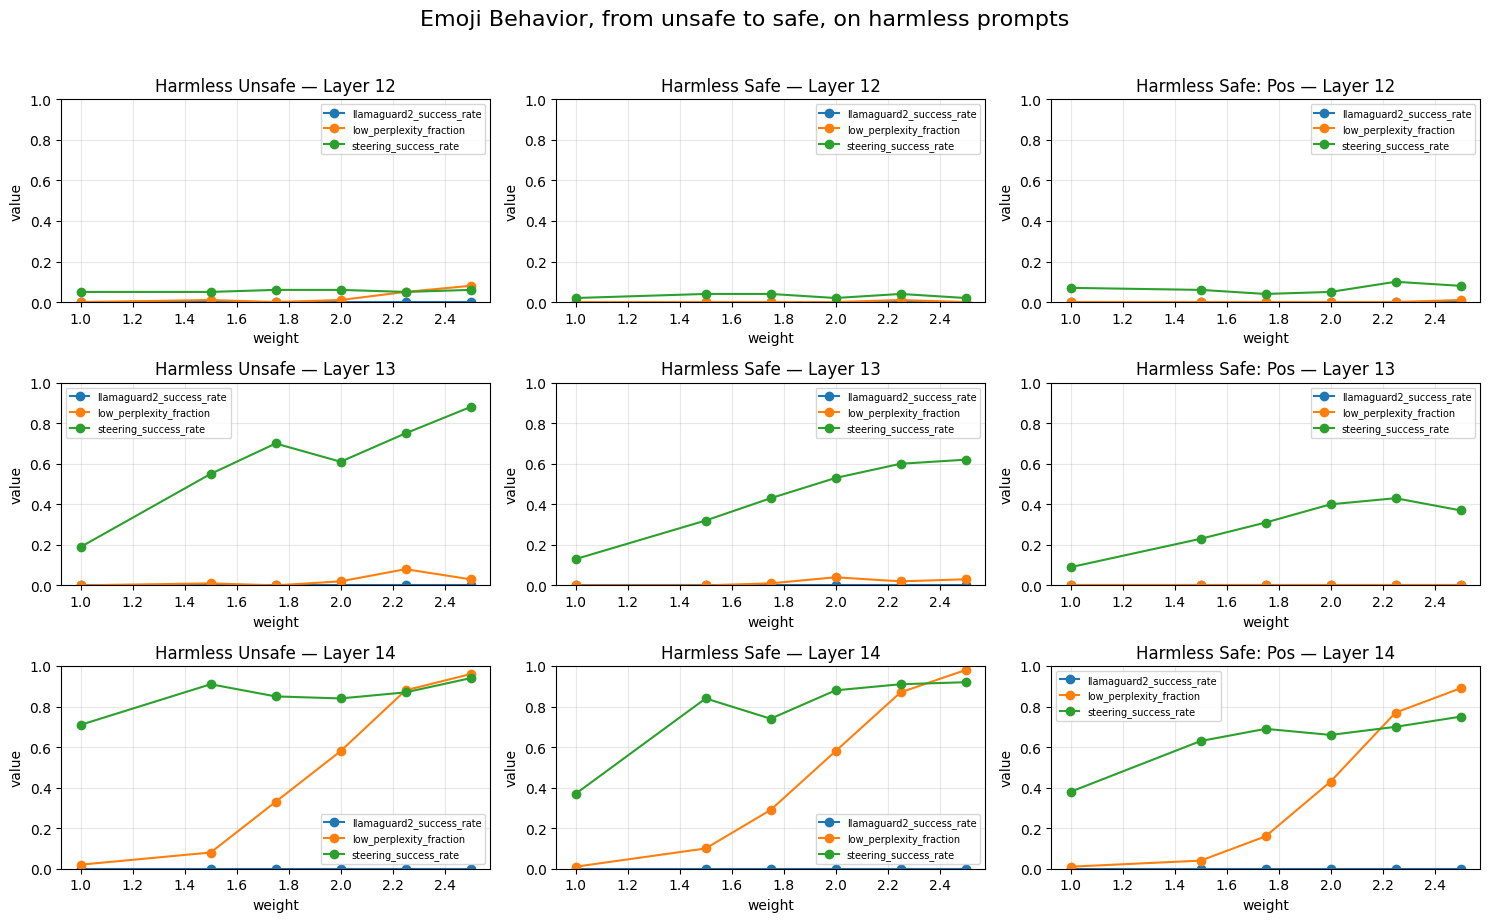

In [10]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
FILE_PATHS = [
    "/root/modular-steering-vectors/results/emoji_-2_harmless_unsafe/results",
    "/root/modular-steering-vectors/results/emoji_-2_harmless_safe/results",
    "/root/modular-steering-vectors/results/emoji_-2_harmless_safe_pos/results"
]
LABELS = ["Harmless Unsafe", "Harmless Safe", "Harmless Safe: Pos"]  # Column labels
# -------------------------------------------

# Load data
dfs = []
for path in FILE_PATHS:
    with open(path, "r") as f:
        data = json.load(f)
    dfs.append(pd.DataFrame(data))

# Get all layers and metrics
all_layers = sorted(set().union(*[df["layer"].unique() for df in dfs]))
metric_cols = sorted(set(dfs[0].columns) - {"layer", "weight", "mean_perplexity"})

# Create plot: rows = layers, columns = 3 files
fig, axes = plt.subplots(len(all_layers), 3, figsize=(15, 3*len(all_layers)))
if len(all_layers) == 1:
    axes = axes.reshape(1, -1)

# Add a main title at the top
fig.suptitle("Emoji Behavior, from unsafe to safe, on harmless prompts", fontsize=16, y=1.02)

for row, layer in enumerate(all_layers):
    for col, (df, label) in enumerate(zip(dfs, LABELS)):
        ax = axes[row, col]
        sub = df[df["layer"] == layer].sort_values("weight")
        
        ax.set_title(f"{label} — Layer {layer}")
        ax.set_xlabel("weight")
        ax.set_ylabel("value")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1)
        
        if sub.empty:
            continue
            
        for metric in metric_cols:
            if metric in sub.columns:
                ax.plot(sub["weight"], sub[metric], marker="o", label=metric)
        
        ax.legend(fontsize=7, loc="best")

fig.tight_layout()
plt.show()